In [3]:
#@title Welcome to LLM (Enhance US Sector Portfolio)
!pip install -q feedparser # for reading RSS feed

import pandas as pd
import urllib.parse, feedparser
from datetime import datetime, timedelta

# Get the default start/end date as current week
DATE_FORMAT = '%Y-%m-%d'
today_date = (datetime.now() + timedelta(days=1)).strftime(DATE_FORMAT)
seven_days_ago = (datetime.now() - timedelta(days=7)).strftime(DATE_FORMAT)

# Enable Google interactive table
from google.colab import data_table
data_table.enable_dataframe_formatter()

# Display LLM output text
from IPython.display import Markdown, display

def displayLLMOutput(llmOutput):
  display(Markdown(f"<font size='4'>{llmOutput}</font>"))

from google.colab import ai
displayLLMOutput("The free LLM models from Google Colab:")
displayLLMOutput(ai.list_models())

<font size='4'>The free LLM models from Google Colab:</font>

<font size='4'>['google/gemini-2.5-flash', 'google/gemini-2.5-flash-lite', 'google/gemini-2.5-pro', 'google/gemini-3.1-pro-preview', 'google/gemini-3.5-flash']</font>

## Part1 Use **RSS feed** to get the news for the 5 Top Performing S&P 500 sectors. Then use LLM to summarize it and provide resaons for Market/Sector Movement and give ideas to construct portfolio to best S&P500.  


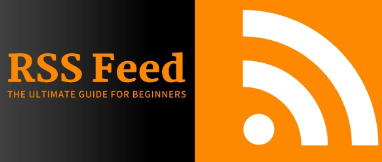

In [4]:
!pip install feedparser -q

In [5]:
# @title Part 1.1. S&P 500 & 11 Sectors Performance Tracker & News Headlines
# @markdown Run this cell to compute the S&P 500 + 11 sector performance and fetch news headlines for the top 5 performers.

from datetime import datetime, timedelta
import time
import urllib.parse
import feedparser
import pandas as pd
import yfinance as yf

# 1. Map S&P 500 and the 11 Sector SPDR ETFs to names and search queries
index_info = {
    "^GSPC": {
        "name": "S&P 500 (Benchmark)",
        "query": "S&P 500 index stock market",
    },
    "XLK": {
        "name": "Information Technology",
        "query": "tech stocks S&P 500 technology sector",
    },
    "XLF": {
        "name": "Financials",
        "query": "financial stocks S&P 500 banking sector",
    },
    "XLV": {
        "name": "Health Care",
        "query": "healthcare stocks S&P 500 pharma sector",
    },
    "XLY": {
        "name": "Consumer Discretionary",
        "query": "consumer discretionary stocks S&P 500 retail",
    },
    "XLC": {
        "name": "Communication Services",
        "query": "communication services stocks media interactive media",
    },
    "XLI": {
        "name": "Industrials",
        "query": "industrial stocks S&P 500 aerospace defense",
    },
    "XLP": {
        "name": "Consumer Staples",
        "query": "consumer staples stocks S&P 500 household goods",
    },
    "XLE": {
        "name": "Energy",
        "query": "energy stocks oil gas S&P 500 energy sector",
    },
    "XLU": {
        "name": "Utilities",
        "query": "utility stocks S&P 500 utilities sector power",
    },
    "XLRE": {
        "name": "Real Estate",
        "query": "real estate stocks REITs S&P 500 real estate",
    },
    "XLB": {
        "name": "Materials",
        "query": "materials stocks chemicals mining S&P 500",
    },
}

# 2. Interactive Date Parameters for Google Colab
startDate = "2025-11-30"  # @param {type:"date"}
endDate = "2025-12-31"  # @param {type:"date"}

# Adjust query_end_date by +1 day because yfinance `end` parameter is EXCLUSIVE
end_dt = datetime.strptime(endDate, "%Y-%m-%d") + timedelta(days=1)
query_end_date = end_dt.strftime("%Y-%m-%d")

# 3. Fetch Historical Data
tickers = list(index_info.keys())
data = yf.download(
    tickers,
    start=startDate,
    end=query_end_date,  # Uses endDate + 1 day
    progress=False,
    ignore_tz=True,
)

# Extract close prices cleanly across yfinance multi-index formats
if isinstance(data.columns, pd.MultiIndex):
    close_prices = data["Close"].copy()
else:
    close_prices = data.copy()

# Forward-fill & back-fill missing prices for market holidays
close_prices = close_prices.dropna(axis=1, how="all").ffill().bfill()

# Calculate performance percentage
start_vals = close_prices.iloc[0]
end_vals = close_prices.iloc[-1]
performance = ((end_vals - start_vals) / start_vals) * 100

# Verify actual trading dates retrieved
actual_start_date = close_prices.index[0].strftime("%Y-%m-%d")
actual_end_date = close_prices.index[-1].strftime("%Y-%m-%d")

# Build DataFrame
df_perf = pd.DataFrame(
    {"Ticker": performance.index, "Return (%)": performance.values}
)
df_perf["Sector / Asset Name"] = df_perf["Ticker"].map(
    lambda x: index_info.get(x, {}).get("name", x)
)

# Separate overall list and Top 5
df_perf_sorted = df_perf.sort_values(
    by="Return (%)", ascending=False
).reset_index(drop=True)
df_top5 = df_perf_sorted.head(5).copy()

# Print Full Performance Table
df_display = df_perf_sorted[["Sector / Asset Name", "Ticker", "Return (%)"]].copy()
df_display["Return (%)"] = df_display["Return (%)"].apply(lambda x: f"{x:+.2f}%")

print("==================================================")
print(f" S&P 500 & SECTOR PERFORMANCE ({actual_start_date} to {actual_end_date})")
print("==================================================\n")
display(df_display)

# 4. Scrape All RSS News for the Top 5 Performers in Date Range
all_news_data = []

for idx, row in df_top5.iterrows():
    ticker = row["Ticker"]
    name = row["Sector / Asset Name"]
    raw_query = index_info[ticker]["query"]

    # Properly encode full search query including date operators
    full_query = f"{raw_query} after:{startDate} before:{query_end_date}"
    encoded_query = urllib.parse.quote(full_query)
    feed_url = f"https://news.google.com/rss/search?q={encoded_query}&hl=en-US&gl=US&ceid=US:en"

    feed = feedparser.parse(feed_url)

    for entry in feed.entries:
        all_news_data.append({
            "Sector / Index": name,
            "Ticker": ticker,
            "Publication Date": getattr(entry, "published", "N/A"),
            "Title": entry.title,
            "Link": entry.link,
        })

    # Polite delay to prevent rate-limiting
    time.sleep(0.5)

# 5. Create and Display Aggregated News DataFrame
df_news = pd.DataFrame(all_news_data)

print("\n" + "=" * 50)
print(
    f" 📰 RSS NEWS HEADLINES FOR TOP 5 PERFORMERS ({len(df_news)} TOTAL FOUND)"
)
print("=" * 50 + "\n")

if not df_news.empty:
    display(df_news)
else:
    print("No news articles found for the given criteria.")

 S&P 500 & SECTOR PERFORMANCE (2025-12-01 to 2025-12-31)



,Sector / Asset Name,Ticker,Return (%)
0,Financials,XLF,+3.92%
1,Communication Services,XLC,+2.83%
2,Industrials,XLI,+2.78%
3,Materials,XLB,+2.23%
4,Consumer Discretionary,XLY,+1.14%
5,Information Technology,XLK,+0.71%
6,S&P 500 (Benchmark),^GSPC,+0.48%
7,Health Care,XLV,+0.11%
8,Real Estate,XLRE,-0.73%
9,Consumer Staples,XLP,-1.24%



 📰 RSS NEWS HEADLINES FOR TOP 5 PERFORMERS (154 TOTAL FOUND)



,Sector / Index,Ticker,Publication Date,Title,Link
0,Financials,XLF,"Tue, 30 Dec 2025 08:00:00 GMT",Bank Stocks Shine in 2025: 3 S&P 500 Plays to ...,https://news.google.com/rss/articles/CBMiekFVX...
1,Financials,XLF,"Sun, 14 Dec 2025 08:00:00 GMT",1 Bank Stock with Exciting Potential and 2 We ...,https://news.google.com/rss/articles/CBMitAFBV...
2,Financials,XLF,"Mon, 08 Dec 2025 08:00:00 GMT",3 reasons we now favor the healthcare sector -...,https://news.google.com/rss/articles/CBMivAFBV...
3,Financials,XLF,"Thu, 11 Dec 2025 08:00:00 GMT",3 Bank Stocks You'll Want to Own in 2026 - The...,https://news.google.com/rss/articles/CBMiigFBV...
4,Financials,XLF,"Mon, 01 Dec 2025 08:00:00 GMT",A top strategist says get ready for the S&P 50...,https://news.google.com/rss/articles/CBMirgFBV...
...,...,...,...,...,...
149,Consumer Discretionary,XLY,"Wed, 24 Dec 2025 08:00:00 GMT",Best Retail Stocks in Canada For 2026 - Millio...,https://news.google.com/rss/articles/CBMifEFVX...
150,Consumer Discretionary,XLY,"Fri, 26 Dec 2025 08:00:00 GMT",Global investing: Here is all that Indian inve...,https://news.google.com/rss/articles/CBMixwFBV...
151,Consumer Discretionary,XLY,"Tue, 30 Dec 2025 12:17:21 GMT",Top Five S&P 500 Gainers In 2025: The Highest-...,https://news.google.com/rss/articles/CBMiogFBV...
152,Consumer Discretionary,XLY,"Thu, 01 Jan 2026 08:00:00 GMT",Rare Wall Street unanimous 2026 call means Nvi...,https://news.google.com/rss/articles/CBMiowFBV...


In [6]:
# ==============================================================================
# Prepare Headlines & Summarize using AI (Sector Tracking Version)
# ==============================================================================
from google.colab import ai
from IPython.display import Markdown, display

# Check if we have gathered any news before attempting to summarize
if not df_news.empty:

  # Group headlines by 'Sector / Asset Name' (updated for sector script output)
  formatted_headlines = []
  for name, group in df_news.groupby("Sector / Index"):
    formatted_headlines.append(f"### Sector / Index: {name}")
    for idx, row in group.iterrows():
      formatted_headlines.append(
          f"- {row['Title']} (Published: {row['Publication Date']})"
      )
    formatted_headlines.append("")  # Blank line separator

  # Combine into a single formatted context string
  all_headlines = "\n".join(formatted_headlines)

  # @title Part 1.2 . Summarise Sector News
  question = "Summarise the news for each top performing sector or index briefly based on the provided headlines."  # @param {type:"string"}
  questionWithContext = (
      question + " Use the following context:\n\n" + all_headlines
  )

  # Generate and display output using Google Colab's built-in AI module
  result = ai.generate_text(questionWithContext)

  # Render the result cleanly as Markdown
  display(Markdown(result))

else:
  print("No headlines found to summarize.")

Based on the provided headlines, here is a brief summary of the news for each sector:

### Communication Services
* **Top Performers & M&A:** EchoStar (driven by SpaceX speculation), Warner Bros. Discovery (boosted by M&A activity), and Fubo TV emerged as top-performing stocks in 2025. 
* **Corporate & Tech Deals:** Major transactions shaped the sector, including SoftBank's $4 billion acquisition of DigitalBridge and Meta's purchase of AI startup Manus. Additionally, Trump Media announced a $6 billion fusion energy deal with TAE, and Liberty Media completed its split-off of Liberty Live Holdings.
* **Regulation & International News:** Regulatory developments made headlines as Australia attempted a first-of-its-kind teen social media ban, and Virgin Media was fined £24 million in the UK. In Canada, Rogers launched a new satellite-to-mobile service.

### Consumer Discretionary
* **Retail Performance:** Walmart stock rose 25% in 2025, while Costco faced its worst relative performance to the S&P 500 in 23 years. Target braced for a potentially weak holiday season, and Kraft Heinz's CEO prepared to oversee a corporate split and asset sales.
* **Stock Winners & Losers:** Carvana was added to the S&P 500 after a volatile ride, and Celsius (CELH) surged 65% in 2025. Conversely, Nike lost value for the fourth consecutive year, and The Trade Desk was noted as the worst-performing S&P 500 stock of 2025. 
* **Macro Environment:** Investors are tracking high-growth, high-inflation economic projections, interest rate cuts by the Fed, and persistent cost pressures on retail and apparel brands.

### Financials
* **Strong Bank Earnings:** Bank stocks rallied in 2025 as US banking profits reached a decade high in the third quarter. In Canada, bank stocks helped push the S&P/TSX composite to historic highs.
* **Bullish 2026 Forecasts:** Wall Street firms released highly optimistic 2026 forecasts, with several major banks predicting the S&P 500 could reach as high as 8,000, driven by AI gains and a cyclical rotation.
* **Corporate Expansion:** PayPal applied to form a bank to offer savings accounts and loans to small businesses.

### Industrials
* **Aerospace & Defense Boom:** Defense stocks are surging due to rising geopolitical tensions and reshoring trends, with ETFs tied to U.S. industrial onshoring outperforming the S&P 500. GE Aerospace led top stock lists, and Boeing outperformed the market on expectations of positive cash flow and higher jet deliveries.
* **Mixed Performance:** Despite the broader sector strength, defense contractor RTX lagged behind the market, and Rocket Lab saw its stock price slide despite celebrating key operational successes. 

### Materials
* **Precious Metals Exposure:** Sector news highlighted the GDX and SIL ETFs, emphasizing that they offer investors indirect exposure to gold and silver with distinct structural differences.

In [7]:
#@title Part 1.3 Based on the news summary. Create Invesment Strategies on Sectors

question = "You are an investment strategist, write some short to mid term sector investment advice. Give weighting for each sectors (Use sector to construct a portfolio that can beat S&P500) , total weighting 100%, max weight for each sector=20%" # @param ["What is the overall sentiment? Provide a sentiment score between -1 to 1 and elaborate your reasons", "You are an investment analyst, write some long term investment advice", "You are a momentum trader, provide some short term trading ideas"] {allow-input: true}
questionWithContext = question + "  Use the following context: \n\n" + result

result = ai.generate_text(questionWithContext)
displayLLMOutput(result)

<font size='4'>As an investment strategist, my short-to-mid-term objective is to construct a tactical, sector-allocated portfolio designed to outperform the S&P 500. 

Based on the provided market intelligence, we are in an environment characterized by **high-growth, high-inflation macro projections, a cyclical rotation, and robust corporate earnings in specific pockets**, balanced against regulatory hurdles and margin pressures in retail. 

To beat the benchmark while respecting risk parameters (maximum 20% per sector, 100% total allocation), we are maxing out our exposure to secular and cyclical leaders (**Financials** and **Industrials**), taking a highly opportunistic position in **Communication Services**, and underweighting macro-sensitive sectors like **Consumer Discretionary**.

---

### **Tactical Sector Allocation Portfolio**

| Sector | Tactical Stance | Portfolio Weight |
| :--- | :--- | :---: |
| **Financials** | Overweight (Max Cap) | **20.0%** |
| **Industrials** | Overweight (Max Cap) | **20.0%** |
| **Communication Services** | Moderately Overweight | **15.0%** |
| **Information Technology** | Strategic Hold | **15.0%** |
| **Consumer Discretionary** | Underweight | **10.0%** |
| **Health Care** | Defensive Anchor | **10.0%** |
| **Materials** | Tactical Underweight | **5.0%** |
| **Other (Staples, Utilities, Energy, Real Estate)** | Underweight Funding Source | **5.0%** |
| **Total** | | **100.0%** |

---

### **Sector Rationales & Strategy**

#### **1. Financials: 20.0% (Overweight - MAX CAP)**
* **Outlook:** Highly Bullish. 
* **Rationale:** The financial sector is our primary growth engine. Banking profits have reached a decade high, and S&P/TSX historic highs indicate systemic North American strength. Crucially, Wall Street's bold forecasts (targeting S&P 8,000) rely on a "cyclical rotation" that directly benefits banks. Furthermore, PayPal’s expansion into small business banking signals a high-margin, tech-driven credit expansion. We max out this sector to capture rising net interest margins and robust capital markets activity.

#### **2. Industrials: 20.0% (Overweight - MAX CAP)**
* **Outlook:** Highly Bullish.
* **Rationale:** Driven by structural tailwinds including rising geopolitical tensions and reshoring. U.S. industrial onshoring ETFs are actively outperforming the S&P 500. GE Aerospace is demonstrating stellar leadership, and Boeing’s projected positive cash flow and jet delivery recovery provide a strong cyclical rebound play. We are maxing out Industrials to capture these high-conviction defense and aerospace tailwinds.

#### **3. Communication Services: 15.0% (Moderately Overweight)**
* **Outlook:** Opportunistic / Bullish.
* **Rationale:** This sector is experiencing intense, value-unlocking M&A and corporate restructuring (e.g., SoftBank’s $4B DigitalBridge acquisition, Meta's Manus acquisition, and Liberty Media’s split-off). While international regulatory headwinds (Australia's teen social media ban and UK telecom fines) exist, the combination of high-performing momentum stocks (EchoStar, Fubo, WBD) and tech innovation (satellite-to-mobile) justifies a heavy overweight position to capture alpha.

#### **4. Information Technology: 15.0% (Strategic Hold)**
* **Outlook:** Neutral-Positive (Underweight S&P 500 benchmark weight due to 20% cap constraint).
* **Rationale:** AI remains the primary catalyst for Wall Street's optimistic 8,000-point target. Because the 20% maximum sector constraint prevents us from holding Tech at its S&P 500 index weight (~30%), we hold it at 15% to remain exposed to systemic AI gains while allocating our risk budget to more favorably valued cyclicals (Financials and Industrials). 

#### **5. Consumer Discretionary: 10.0% (Underweight)**
* **Outlook:** Cautious / Highly Selective.
* **Rationale:** This sector is heavily bifurcated and highly vulnerable to the "high-growth, high-inflation" macro projections and persistent cost pressures. For every winner (Walmart up 25%, Celsius up 65%), there is a major laggard (Costco’s worst relative performance in 23 years, Target's weak holiday season, Nike's multi-year decline, and The Trade Desk's underperformance). We are underweighting the broader sector to protect the portfolio from margin compression, advising a stock-picker's approach focused strictly on discount retail and high-growth beverage/auto-retail (e.g., Carvana).

#### **6. Health Care: 10.0% (Defensive Anchor)**
* **Outlook:** Neutral.
* **Rationale:** Actively utilized as a defensive counterweight. In a "high-inflation" environment, Health Care provides inelastic earnings and dividend support to balance out the high-beta profile of our Communication Services and Industrial holdings.

#### **7. Materials: 5.0% (Tactical Underweight)**
* **Outlook:** Selective Hedging.
* **Rationale:** The macro environment of persistent inflation makes hard assets attractive. Rather than broad materials exposure, we recommend using this 5% allocation to target precious metals. Utilizing GDX (gold miners) and SIL (silver miners) ETFs provides a leveraged, structural hedge against inflation and geopolitical instability without over-allocating to capital-intensive chemical or paper cyclicals.

#### **8. Other Sectors (Staples, Utilities, Real Estate, Energy): 5.0% (Underweight)**
* **Outlook:** Bearish/Funding Source.
* **Rationale:** Capital has been aggressively harvested from these yield-sensitive and capital-intensive sectors to fund our high-conviction allocations in Financials and Industrials. This lean allocation keeps us focused strictly on sectors with the strongest near-term catalysts.</font>

In [15]:
# @title Part2 Use LLM ideas to construct portfolio to beat S&P500, Automated Optimization Engines (With Constraint Bounds): Test with "Max Sharpe ratio" top enhance portfolio

In [1]:
!pip install --upgrade yfinance ipywidgets pandas --no-cache-dir

In [8]:
from google.colab import output
output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [9]:
# @title Part 2.1 🇺🇸 US 11-Sector Portfolio Tracker & Optimization Engine (With Sector Cap Slider)
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.optimize as sco
from datetime import date, datetime, timedelta
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown, HTML
import plotly.graph_objects as go

# 1. Map of 11 GICS Sector SPDR ETFs + S&P 500 Benchmark
sector_info = {
    "XLK": "Information Technology",
    "XLF": "Financials",
    "XLV": "Health Care",
    "XLY": "Consumer Discretionary",
    "XLC": "Communication Services",
    "XLI": "Industrials",
    "XLP": "Consumer Staples",
    "XLU": "Utilities",
    "XLE": "Energy",
    "XLRE": "Real Estate",
    "XLB": "Materials"
}

BENCHMARK_TICKER = "SPY"
BENCHMARK_NAME = "S&P 500 (SPY)"

ticker_by_name = {v: k for k, v in sector_info.items()}
all_sector_names = list(sector_info.values())

# 2. UI Elements Initialization
portfolio_rows = []
portfolio_container = widgets.VBox()
output_area = widgets.Output()

# Dynamic Status Banner
total_weight_label = widgets.HTML()

today_date = date.today()
default_start = today_date - timedelta(days=365)

start_date_picker = widgets.DatePicker(description='Start Date:', value=default_start)
end_date_picker = widgets.DatePicker(description='End Date:', value=today_date)
rf_rate_input = widgets.BoundedFloatText(value=4.0, min=0.0, max=20.0, step=0.1, description='Risk-Free Rate (%):', style={'description_width': 'initial'})

# New Constraint: Maximum Sector Allocation Cap Slider
max_sector_cap_slider = widgets.IntSlider(
    value=25,
    min=10,
    max=100,
    step=5,
    description='Max Sector Cap (%):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px')
)

# Action & Optimization Buttons
add_button = widgets.Button(description="➕ Add Sector", button_style='success', icon='plus')
equal_weight_button = widgets.Button(description="⚖️ Equal Weight All", button_style='info', icon='balance-scale')
reset_button = widgets.Button(description="🔄 Reset (0%)", button_style='warning', icon='refresh')
calc_button = widgets.Button(description="🚀 Run Comparison vs S&P 500", button_style='primary', icon='calculator')

opt_sharpe_btn = widgets.Button(description="🎯 Max Sharpe Weights", button_style='primary')
opt_minvol_btn = widgets.Button(description="🛡️ Min Risk Weights", button_style='info')
opt_alpha_btn = widgets.Button(description="🚀 Max Outperformance Weights", button_style='success')

def sync_container_children():
    """Forces explicit redraw of the list box for Google Colab UI."""
    portfolio_container.children = [r['box'] for r in portfolio_rows]

def update_total_display():
    """Updates overall weight status bar in real-time as inputs or sliders change."""
    current_total = sum(r['text'].value for r in portfolio_rows)
    if current_total == 100:
        color = "#28a745"
        status_txt = "Ready (100% Fully Allocated)"
    elif current_total < 100:
        color = "#fd7e14"
        status_txt = f"Underallocated by {100 - current_total}%"
    else:
        color = "#dc3545"
        status_txt = "Overallocated (> 100%)"

    total_weight_label.value = (
        f"<div style='font-family: sans-serif; padding: 8px 12px; border-radius: 5px; background-color: #f8f9fa; border: 1px solid #dee2e6; margin-bottom: 10px;'>"
        f"<b>Total Allocation: <span style='color:{color}; font-size:18px;'>{current_total}% / 100%</span></b> "
        f"<span style='color:{color}; font-size:13px; margin-left:10px;'>({status_txt})</span>"
        f"</div>"
    )

def enforce_max_total_limit(change):
    """Clamps typed or slider-adjusted weight so sum across all rows never exceeds 100%."""
    widget_changed = change['owner']

    target_row = None
    for r in portfolio_rows:
        if r['slider'] == widget_changed or r['text'] == widget_changed:
            target_row = r
            break

    if target_row:
        other_sum = sum(r['text'].value for r in portfolio_rows if r != target_row)
        max_allowed = max(0, 100 - other_sum)

        new_val = change['new'] if change['new'] is not None else 0

        if new_val > max_allowed:
            target_row['slider'].value = max_allowed
            target_row['text'].value = max_allowed
        else:
            if target_row['slider'].value != new_val:
                target_row['slider'].value = new_val
            if target_row['text'].value != new_val:
                target_row['text'].value = new_val

    update_total_display()

def create_portfolio_row(selected_name=None, weight_val=0):
    if selected_name is None:
        selected_name = all_sector_names[0]

    dropdown = widgets.Dropdown(
        options=all_sector_names,
        value=selected_name,
        layout=widgets.Layout(width='240px')
    )

    weight_text = widgets.BoundedIntText(
        value=weight_val,
        min=0,
        max=100,
        step=1,
        description='Weight (%):',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='150px')
    )

    weight_slider = widgets.IntSlider(
        value=weight_val,
        min=0,
        max=100,
        step=1,
        readout=False,
        layout=widgets.Layout(width='180px')
    )

    remove_btn = widgets.Button(
        description="❌ Remove",
        button_style='danger',
        layout=widgets.Layout(width='100px')
    )

    weight_text.observe(enforce_max_total_limit, names='value')
    weight_slider.observe(enforce_max_total_limit, names='value')

    row_box = widgets.HBox([dropdown, weight_text, weight_slider, remove_btn], layout=widgets.Layout(align_items='center', margin='2px 0px'))
    row_data = {
        'box': row_box,
        'dropdown': dropdown,
        'text': weight_text,
        'slider': weight_slider,
        'remove_btn': remove_btn
    }

    def on_remove_clicked(b):
        if len(portfolio_rows) > 1:
            portfolio_rows.remove(row_data)
            sync_container_children()
            update_total_display()

    remove_btn.on_click(on_remove_clicked)
    return row_data

# Populate initial default sectors
initial_sectors = ["Information Technology", "Financials", "Health Care", "Consumer Discretionary"]
default_weights = [35, 25, 20, 20]

for name, w in zip(initial_sectors, default_weights):
    portfolio_rows.append(create_portfolio_row(selected_name=name, weight_val=w))

sync_container_children()
update_total_display()

def add_new_row(event=None):
    current_selected = [r['dropdown'].value for r in portfolio_rows]
    available = [n for n in all_sector_names if n not in current_selected]
    if not available:
        return
    next_name = available[0]

    new_row = create_portfolio_row(selected_name=next_name, weight_val=0)
    portfolio_rows.append(new_row)
    sync_container_children()
    update_total_display()

def set_equal_weights(event=None):
    """Adds all 11 sectors to the panel and splits weights equally."""
    portfolio_rows.clear()
    eq_weight = int(100 / len(all_sector_names))
    remainder = 100 - (eq_weight * len(all_sector_names))

    for idx, name in enumerate(all_sector_names):
        w = eq_weight + 1 if idx < remainder else eq_weight
        portfolio_rows.append(create_portfolio_row(selected_name=name, weight_val=w))

    sync_container_children()
    update_total_display()

def reset_all_weights(event=None):
    """Reset all text values and sliders to 0%."""
    for r in portfolio_rows:
        r['text'].value = 0
        r['slider'].value = 0
    update_total_display()

add_button.on_click(add_new_row)
equal_weight_button.on_click(set_equal_weights)
reset_button.on_click(reset_all_weights)

# 3. Analytics & Plotting Engine
def calculate_portfolio_metrics(event=None):
    output_area.clear_output(wait=True)

    with output_area:
        start_val = start_date_picker.value
        end_val = min(end_date_picker.value, date.today())

        if start_val >= end_val:
            display(Markdown("❌ **Error:** Start Date must be earlier than End Date."))
            return

        start_d = start_val.strftime('%Y-%m-%d')
        end_d = (end_val + timedelta(days=1)).strftime('%Y-%m-%d')
        rf_annual = rf_rate_input.value / 100.0

        active_items = []
        raw_weights = []

        for r in portfolio_rows:
            if r['text'].value > 0:
                active_items.append(r['dropdown'].value)
                raw_weights.append(r['text'].value)

        if not active_items or sum(raw_weights) == 0:
            display(Markdown("❌ **Error:** Total sector portfolio weight must be greater than 0%."))
            return

        raw_weights = np.array(raw_weights, dtype=float)
        active_tickers = [ticker_by_name[name] for name in active_items]
        download_tickers = list(set(active_tickers + [BENCHMARK_TICKER]))

        display(Markdown("⏳ *Downloading sector ETF & S&P 500 market data from Yahoo Finance...*"))

        try:
            df_download = yf.download(
                tickers=download_tickers,
                start=start_d,
                end=end_d,
                progress=False,
                auto_adjust=True
            )
        except Exception as e:
            output_area.clear_output()
            display(Markdown(f"❌ **Network Error:** `{e}`"))
            return

        if df_download.empty:
            output_area.clear_output()
            display(Markdown("❌ **Data Error:** Yahoo Finance returned empty dataset."))
            return

        if isinstance(df_download.columns, pd.MultiIndex):
            if 'Close' in df_download.columns.levels[0]:
                close_prices = df_download['Close'].copy()
            else:
                close_prices = df_download.xs(df_download.columns.levels[0][0], axis=1, level=0)
        else:
            close_prices = df_download[['Close']] if 'Close' in df_download.columns else df_download.copy()

        close_prices = close_prices.ffill().bfill().dropna(axis=1, how='all')

        if BENCHMARK_TICKER not in close_prices.columns:
            output_area.clear_output()
            display(Markdown(f"❌ **Error:** Could not retrieve benchmark ticker `{BENCHMARK_TICKER}`."))
            return

        valid_tickers = [t for t in active_tickers if t in close_prices.columns]
        valid_indices = [active_items[i] for i, t in enumerate(active_tickers) if t in valid_tickers]
        valid_raw_weights = [raw_weights[i] for i, t in enumerate(active_tickers) if t in valid_tickers]
        valid_weights = np.array(valid_raw_weights) / np.sum(valid_raw_weights)

        daily_returns = close_prices[valid_tickers + [BENCHMARK_TICKER]].pct_change().dropna()

        if daily_returns.empty:
            output_area.clear_output()
            display(Markdown("❌ **Error:** Insufficient date overlap to calculate returns."))
            return

        portfolio_daily = daily_returns[valid_tickers].dot(valid_weights)
        benchmark_daily = daily_returns[BENCHMARK_TICKER]

        portfolio_cum = (1 + portfolio_daily).cumprod()
        benchmark_cum = (1 + benchmark_daily).cumprod()

        def calc_max_drawdown(cum_series):
            running_max = cum_series.cummax()
            dd = (cum_series - running_max) / running_max
            return dd.min() * 100

        port_mdd = calc_max_drawdown(portfolio_cum)
        bench_mdd = calc_max_drawdown(benchmark_cum)

        def get_stats(daily_s, cum_s, mdd_val):
            total_ret = (cum_s.iloc[-1] - 1) * 100
            ann_std = daily_s.std() * np.sqrt(252) * 100
            ann_ret = ((1 + daily_s.mean()) ** 252) - 1
            sharpe = (ann_ret - rf_annual) / (daily_s.std() * np.sqrt(252))
            return total_ret, ann_std, mdd_val, sharpe

        p_tot, p_vol, p_mdd, p_sh = get_stats(portfolio_daily, portfolio_cum, port_mdd)
        b_tot, b_vol, b_mdd, b_sh = get_stats(benchmark_daily, benchmark_cum, bench_mdd)

        cov_matrix = np.cov(portfolio_daily, benchmark_daily)
        beta = cov_matrix[0, 1] / cov_matrix[1, 1]
        tracking_error = (portfolio_daily - benchmark_daily).std() * np.sqrt(252) * 100
        alpha = ((p_tot - rf_annual * 100) - beta * (b_tot - rf_annual * 100))

        df_weights = pd.DataFrame({
            "Sector": valid_indices,
            "ETF Ticker": valid_tickers,
            "Selected Alloc (%)": valid_raw_weights,
            "Effective Weight (%)": np.round(valid_weights * 100, 2)
        })

        output_area.clear_output()
        display(Markdown("---"))
        display(Markdown("### 📊 Portfolio Holdings Breakdown"))
        display(HTML(df_weights.to_html(index=False, classes='table table-striped')))

        comp_df = pd.DataFrame({
            "Metric": ["Total Return (%)", "Annualized Volatility (%)", "Max Drawdown (%)", "Sharpe Ratio", "Beta vs S&P 500", "Alpha (%)", "Tracking Error (%)"],
            "Sector Portfolio": [f"{p_tot:+.2f}%", f"{p_vol:.2f}%", f"{p_mdd:.2f}%", f"{p_sh:.2f}", f"{beta:.2f}", f"{alpha:+.2f}%", f"{tracking_error:.2f}%"],
            "S&P 500 (Benchmark)": [f"{b_tot:+.2f}%", f"{b_vol:.2f}%", f"{b_mdd:.2f}%", f"{b_sh:.2f}", "1.00", "0.00%", "0.00%"],
            "Outperformance / Spread": [f"{p_tot - b_tot:+.2f}%", f"{p_vol - b_vol:+.2f}%", f"{p_mdd - b_mdd:+.2f}%", f"{p_sh - b_sh:+.2f}", "-", "-", "-"]
        })

        display(Markdown("### ⚔️ Sector Portfolio vs S&P 500 Comparison"))
        display(HTML(comp_df.to_html(index=False, classes='table table-hover table-bordered')))

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=portfolio_cum.index,
            y=(portfolio_cum - 1) * 100,
            mode='lines',
            name='Custom Sector Portfolio',
            line=dict(color='#007bff', width=2.5)
        ))
        fig.add_trace(go.Scatter(
            x=benchmark_cum.index,
            y=(benchmark_cum - 1) * 100,
            mode='lines',
            name='S&P 500 (SPY Benchmark)',
            line=dict(color='#28a745', width=2, dash='dash')
        ))

        fig.update_layout(
            title="📈 Cumulative Return Growth (%) vs S&P 500 Benchmark",
            xaxis_title="Date",
            yaxis_title="Cumulative Return (%)",
            hovermode="x unified",
            template="plotly_white",
            margin=dict(l=40, r=40, t=50, b=40),
            legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
        )

        fig.show()

calc_button.on_click(calculate_portfolio_metrics)

# 4. Optimization Engine Function (With Sector Weight Cap Enforced)
def run_portfolio_optimization(method="sharpe"):
    output_area.clear_output(wait=True)
    with output_area:
        start_val = start_date_picker.value
        end_val = min(end_date_picker.value, date.today())
        rf_annual = rf_rate_input.value / 100.0
        max_cap = max_sector_cap_slider.value / 100.0  # Convert slider % to fraction

        num_assets = len(all_sector_names)
        if max_cap * num_assets < 1.0:
            display(Markdown(f"❌ **Constraint Error:** The single-sector cap of `{max_sector_cap_slider.value}%` across `{num_assets}` sectors sums to `{max_sector_cap_slider.value * num_assets}%`, which is less than 100%. Increase the cap slider to at least `{int(np.ceil(100/num_assets))}%`."))
            return

        all_tickers = list(sector_info.keys())
        download_tickers = list(set(all_tickers + [BENCHMARK_TICKER]))

        display(Markdown(f"⏳ *Running optimization algorithm on historical market data (Enforcing Max Sector Cap: **{max_sector_cap_slider.value}%**)...*"))

        df_download = yf.download(
            tickers=download_tickers,
            start=start_val.strftime('%Y-%m-%d'),
            end=(end_val + timedelta(days=1)).strftime('%Y-%m-%d'),
            progress=False,
            auto_adjust=True
        )

        if isinstance(df_download.columns, pd.MultiIndex):
            close_prices = df_download['Close'].copy() if 'Close' in df_download.columns.levels[0] else df_download.xs(df_download.columns.levels[0][0], axis=1, level=0)
        else:
            close_prices = df_download[['Close']] if 'Close' in df_download.columns else df_download.copy()

        close_prices = close_prices.ffill().bfill().dropna(axis=1, how='all')
        daily_returns = close_prices.pct_change().dropna()

        sector_returns = daily_returns[all_tickers]
        benchmark_returns = daily_returns[BENCHMARK_TICKER]

        mean_returns = sector_returns.mean() * 252
        cov_matrix = sector_returns.cov() * 252

        constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

        # Enforce Upper Bound from Slider: [0.0, max_cap]
        bounds = tuple((0.0, max_cap) for _ in range(num_assets))
        init_weights = num_assets * [1.0 / num_assets]

        def neg_sharpe(w):
            p_ret = np.sum(mean_returns * w)
            p_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
            return -(p_ret - rf_annual) / p_vol if p_vol > 0 else 0

        def portfolio_vol(w):
            return np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))

        def neg_information_ratio(w):
            p_daily = sector_returns.dot(w)
            active_daily = p_daily - benchmark_returns
            tracking_error = active_daily.std() * np.sqrt(252)
            active_return = (p_daily.mean() - benchmark_returns.mean()) * 252
            return -(active_return / tracking_error) if tracking_error > 0 else 0

        if method == "sharpe":
            res = sco.minimize(neg_sharpe, init_weights, method='SLSQP', bounds=bounds, constraints=constraints)
            title_text = "🎯 Maximum Sharpe Ratio Portfolio"
        elif method == "min_vol":
            res = sco.minimize(portfolio_vol, init_weights, method='SLSQP', bounds=bounds, constraints=constraints)
            title_text = "🛡️ Minimum Volatility (Risk Managed) Portfolio"
        elif method == "max_alpha":
            res = sco.minimize(neg_information_ratio, init_weights, method='SLSQP', bounds=bounds, constraints=constraints)
            title_text = "🚀 Maximum Information Ratio (Benchmark Outperformance) Portfolio"

        opt_weights = res.x

        # Populate all 11 sectors into UI rows to reflect full capped allocation
        set_equal_weights()
        for r in portfolio_rows:
            ticker = ticker_by_name[r['dropdown'].value]
            idx = all_tickers.index(ticker)
            w_val = int(round(opt_weights[idx] * 100))
            r['text'].value = w_val
            r['slider'].value = w_val

        update_total_display()

        df_opt = pd.DataFrame({
            "Sector": [sector_info[t] for t in all_tickers],
            "ETF Ticker": all_tickers,
            "Optimal Weight (%)": np.round(opt_weights * 100, 2)
        }).sort_values(by="Optimal Weight (%)", ascending=False)

        output_area.clear_output()
        display(Markdown(f"### {title_text} *(Max Sector Cap: {max_sector_cap_slider.value}%)*"))
        display(Markdown("*(The portfolio weights in your UI above have been automatically updated to these optimal targets).*"))
        display(HTML(df_opt[df_opt["Optimal Weight (%)"] > 0].to_html(index=False, classes='table table-success table-striped')))

# Bind Optimization Click Handlers
opt_sharpe_btn.on_click(lambda b: run_portfolio_optimization("sharpe"))
opt_minvol_btn.on_click(lambda b: run_portfolio_optimization("min_vol"))
opt_alpha_btn.on_click(lambda b: run_portfolio_optimization("max_alpha"))

# 5. Display Main Unified Layout Stack
display(Markdown("## 🇺🇸 US 11-Sector Portfolio Tracker & Automated Optimization Engine"))
display(widgets.HBox([start_date_picker, end_date_picker, rf_rate_input]))
display(widgets.HTML("<hr>"))
display(total_weight_label)
display(portfolio_container)
display(Markdown("#### **Manual Controls & Preset Allocation Actions:**"))
display(widgets.HBox([add_button, equal_weight_button, reset_button, calc_button]))
display(Markdown("#### **Automated Optimization Engines (With Constraint Bounds):**"))
display(widgets.HBox([max_sector_cap_slider, opt_sharpe_btn, opt_minvol_btn, opt_alpha_btn]))
display(output_area)

## 🇺🇸 US 11-Sector Portfolio Tracker & Automated Optimization Engine

HTML(value='<hr>')

HTML(value="<div style='font-family: sans-serif; padding: 8px 12px; border-radius: 5px; background-color: #f8f…

#### **Manual Controls & Preset Allocation Actions:**

#### **Automated Optimization Engines (With Constraint Bounds):**

Output()

In [10]:
# @title Part 2.2 ⚔️ Multi-Lookback Window Engine with Single-Sector Allocation Cap (20% Max)
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.optimize as sco
from datetime import date
import plotly.graph_objects as go
from IPython.display import display, Markdown, HTML

# 1. Define Sector Assets & Benchmark
sector_info = {
    "XLK": "Information Technology", "XLF": "Financials", "XLV": "Health Care",
    "XLY": "Consumer Discretionary", "XLC": "Communication Services", "XLI": "Industrials",
    "XLP": "Consumer Staples", "XLU": "Utilities", "XLE": "Energy",
    "XLRE": "Real Estate", "XLB": "Materials"
}
BENCHMARK_TICKER = "SPY"
tickers = list(sector_info.keys())
all_tickers = tickers + [BENCHMARK_TICKER]

# Config Parameters
START_DATE = "2016-01-01"
END_DATE = date.today().strftime('%Y-%m-%d')
RF_RATE = 0.04
MAX_SECTOR_WEIGHT = 0.20  # 20% Maximum Cap per Sector ETF

LOOKBACK_CONFIGS = {
    "1-Month Lookback": 21,
    "3-Month Lookback": 63,
    "12-Month Lookback": 252
}

print("⏳ Downloading historical market data...")
df = yf.download(all_tickers, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)

prices = df['Close'] if isinstance(df.columns, pd.MultiIndex) else df
prices = prices.ffill().dropna()
daily_returns = prices.pct_change().dropna()

# 2. Max Sharpe Optimization Function with Upper-Bound Constraint
def get_max_sharpe_weights_capped(returns_subset, rf=RF_RATE, max_weight=MAX_SECTOR_WEIGHT):
    num_assets = len(tickers)
    mean_ret = returns_subset.mean() * 252
    cov_mat = returns_subset.cov() * 252

    def neg_sharpe(w):
        p_ret = np.sum(mean_ret * w)
        p_vol = np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))
        return -(p_ret - rf) / p_vol if p_vol > 0 else 0

    # Constraint: Weights sum to 1.0 (100%)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

    # Upper & Lower Bounds: Enforce [0.0, MAX_SECTOR_WEIGHT]
    bounds = tuple((0.0, max_weight) for _ in range(num_assets))
    init_w = num_assets * [1.0 / num_assets]

    res = sco.minimize(neg_sharpe, init_w, method='SLSQP', bounds=bounds, constraints=constraints)
    return res.x

# Identify Rebalance Dates
prices['YearMonth'] = prices.index.to_period('M')
rebalance_dates = prices.groupby('YearMonth').head(1).index

# 3. Walk-Forward Loop for All Lookback Windows
strategy_results = {}
max_lookback = max(LOOKBACK_CONFIGS.values())

for label, lookback_days in LOOKBACK_CONFIGS.items():
    print(f"🔄 Simulating {label} (Capped at {int(MAX_SECTOR_WEIGHT*100)}% Max Weight)...")
    strat_returns = []

    for i in range(len(rebalance_dates) - 1):
        reb_date = rebalance_dates[i]
        next_reb_date = rebalance_dates[i + 1]

        if len(daily_returns.loc[:reb_date]) < max_lookback:
            continue

        hist_subset = daily_returns.loc[:reb_date, tickers].tail(lookback_days)
        opt_w = get_max_sharpe_weights_capped(hist_subset)

        month_returns = daily_returns.loc[reb_date:next_reb_date, tickers].iloc[1:]
        out_of_sample_ret = month_returns.dot(opt_w)
        strat_returns.append(out_of_sample_ret)

    strategy_results[label] = pd.concat(strat_returns)

# Benchmark returns over exact same timeline
first_valid_date = strategy_results["1-Month Lookback"].index[0]
bench_ret = daily_returns.loc[first_valid_date:, BENCHMARK_TICKER]

# 4. Performance Summary Table
def calc_stats(ret_series):
    cum_series = (1 + ret_series).cumprod()
    tot_ret = (cum_series.iloc[-1] - 1) * 100
    ann_vol = ret_series.std() * np.sqrt(252) * 100
    sharpe = ((ret_series.mean() * 252) - RF_RATE) / (ret_series.std() * np.sqrt(252))
    mdd = ((cum_series - cum_series.cummax()) / cum_series.cummax()).min() * 100
    return tot_ret, ann_vol, mdd, sharpe

summary_data = []

for label, ret_s in strategy_results.items():
    tot, vol, mdd, sh = calc_stats(ret_s)
    summary_data.append({
        "Strategy / Window": f"{label} (Max {int(MAX_SECTOR_WEIGHT*100)}% Cap)",
        "Total Return (%)": f"{tot:+.2f}%",
        "Annualized Volatility (%)": f"{vol:.2f}%",
        "Max Drawdown (%)": f"{mdd:.2f}%",
        "Sharpe Ratio": f"{sh:.2f}",
        "Outperformance vs SPY": f"{tot - calc_stats(bench_ret)[0]:+.2f}%"
    })

b_tot, b_vol, b_mdd, b_sh = calc_stats(bench_ret)
summary_data.append({
    "Strategy / Window": "S&P 500 Benchmark (SPY)",
    "Total Return (%)": f"{b_tot:+.2f}%",
    "Annualized Volatility (%)": f"{b_vol:.2f}%",
    "Max Drawdown (%)": f"{b_mdd:.2f}%",
    "Sharpe Ratio": f"{b_sh:.2f}",
    "Outperformance vs SPY": "0.00%"
})

df_summary = pd.DataFrame(summary_data)

display(Markdown(f"### 📊 Performance Comparison: Sector Capped ({int(MAX_SECTOR_WEIGHT*100)}% Max) Strategies vs S&P 500"))
display(HTML(df_summary.to_html(index=False, classes='table table-bordered table-hover')))

⏳ Downloading historical market data...
🔄 Simulating 1-Month Lookback (Capped at 20% Max Weight)...
🔄 Simulating 3-Month Lookback (Capped at 20% Max Weight)...
🔄 Simulating 12-Month Lookback (Capped at 20% Max Weight)...


### 📊 Performance Comparison: Sector Capped (20% Max) Strategies vs S&P 500

Strategy / Window,Total Return (%),Annualized Volatility (%),Max Drawdown (%),Sharpe Ratio,Outperformance vs SPY
1-Month Lookback (Max 20% Cap),+189.94%,18.02%,-31.52%,0.70,+3.90%
3-Month Lookback (Max 20% Cap),+157.34%,17.95%,-31.80%,0.60,-28.70%
12-Month Lookback (Max 20% Cap),+187.49%,17.58%,-31.88%,0.70,+1.45%
S&P 500 Benchmark (SPY),+186.04%,19.64%,-33.72%,0.64,0.00%


In [11]:
# @title Part2.3 🛡️ Max Sharpe Strategy with 20% Single-Sector Weight Cap
import scipy.optimize as sco
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display, Markdown, HTML

# 1. Updated Max Sharpe Optimization Function with 25% Weight Bounds
def get_max_sharpe_weights_capped(returns_subset, rf=RF_RATE, max_weight=0.25):
    """
    Optimizes for Max Sharpe Ratio while enforcing:
      1. Fully invested portfolio: sum(weights) = 1.0
      2. Single-sector allocation cap: 0% <= weight <= max_weight (25%)
    """
    num_assets = len(tickers)
    mean_ret = returns_subset.mean() * 252
    cov_mat = returns_subset.cov() * 252

    def neg_sharpe(w):
        p_ret = np.sum(mean_ret * w)
        p_vol = np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))
        return -(p_ret - rf) / p_vol if p_vol > 0 else 0

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})

    # Updated bounds: Cap upper bound at max_weight (0.25 = 25%)
    bounds = tuple((0.0, max_weight) for _ in range(num_assets))

    # Initial guess split equally
    init_w = num_assets * [1.0 / num_assets]

    res = sco.minimize(neg_sharpe, init_w, method='SLSQP', bounds=bounds, constraints=constraints)
    return res.x

# 2. Run Monthly Rebalancing Backtest with Capped Function (12-Month Lookback)
LOOKBACK_DAYS_12M = 252
weight_history_capped = []
strategy_returns_capped = []

for i in range(len(rebalance_dates) - 1):
    reb_date = rebalance_dates[i]
    next_reb_date = rebalance_dates[i + 1]

    if len(daily_returns.loc[:reb_date]) < LOOKBACK_DAYS_12M:
        continue

    hist_subset = daily_returns.loc[:reb_date, tickers].tail(LOOKBACK_DAYS_12M)

    # Calculate weights with 20% cap
    opt_w = get_max_sharpe_weights_capped(hist_subset, rf=RF_RATE, max_weight=0.20)

    w_series = pd.Series(opt_w, index=tickers, name=reb_date.strftime('%Y-%m'))
    weight_history_capped.append(w_series)

    month_returns = daily_returns.loc[reb_date:next_reb_date, tickers].iloc[1:]
    out_of_sample_ret = month_returns.dot(opt_w)
    strategy_returns_capped.append(out_of_sample_ret)

df_weights_capped = pd.DataFrame(weight_history_capped)
strat_ret_capped = pd.concat(strategy_returns_capped)

# 3. Plot Capped Rebalancing Sector Allocation Bar Chart
fig_capped = go.Figure()

colors = [
    '#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c',
    '#98df8a', '#d62728', '#ff9896', '#9467bd', '#c5b0d5', '#8c564b'
]

for idx, ticker in enumerate(tickers):
    sector_name = sector_info[ticker]
    fig_capped.add_trace(go.Bar(
        x=df_weights_capped.index,
        y=df_weights_capped[ticker] * 100,
        name=f"{ticker} - {sector_name}",
        marker_color=colors[idx % len(colors)]
    ))

fig_capped.update_layout(
    title="📊 Capped Monthly Sector Allocations (Max 20% Per Sector | 12-Month Lookback)",
    xaxis_title="Rebalance Month",
    yaxis_title="Portfolio Weight (%)",
    barmode='stack',
    hovermode="x unified",
    template="plotly_white",
    legend=dict(title="Sector ETFs", yanchor="top", y=0.99, xanchor="left", x=1.02),
    margin=dict(r=150)
)

fig_capped.show()

In [13]:
# @title Part 2.4 🎯 Win Rate & Monthly Outperformance Analytics (20% Capped Strategy vs SPY)
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from IPython.display import display, Markdown, HTML

# 1. Aggregate Daily Returns into Monthly Out-of-Sample Performance
monthly_strat_ret = strat_ret_capped.groupby(strat_ret_capped.index.to_period('M')).apply(lambda x: (1 + x).prod() - 1)
monthly_bench_ret = bench_ret.groupby(bench_ret.index.to_period('M')).apply(lambda x: (1 + x).prod() - 1)

# Align periods
df_monthly = pd.DataFrame({
    'Strategy_Return': monthly_strat_ret,
    'Benchmark_Return': monthly_bench_ret
}).dropna()

# 2. Compute Win Rate & Return Metrics
df_monthly['Spread'] = df_monthly['Strategy_Return'] - df_monthly['Benchmark_Return']
df_monthly['Beat_Benchmark'] = df_monthly['Spread'] > 0

total_months = len(df_monthly)
wins = df_monthly['Beat_Benchmark'].sum()
losses = total_months - wins
win_rate = (wins / total_months) * 100

avg_outperformance = df_monthly['Spread'].mean() * 100
avg_win_margin = df_monthly.loc[df_monthly['Beat_Benchmark'], 'Spread'].mean() * 100
avg_loss_margin = df_monthly.loc[~df_monthly['Beat_Benchmark'], 'Spread'].mean() * 100

# 3. Display Summary Table
win_rate_summary = pd.DataFrame({
    "Metric": [
        "Total Rebalance Months Evaluated",
        "Months Strategy Beat SPY (Wins)",
        "Months Strategy Lagged SPY (Losses)",
        "Monthly Win Rate (%)",
        "Average Monthly Spread vs SPY",
        "Average Margin of Victory (Winning Months)",
        "Average Margin of Defeat (Losing Months)"
    ],
    "Value": [
        f"{total_months}",
        f"{wins}",
        f"{losses}",
        f"{win_rate:.2f}%",
        f"{avg_outperformance:+.2f}%",
        f"{avg_win_margin:+.2f}%",
        f"{avg_loss_margin:+.2f}%"
    ]
})

display(Markdown("### 🏆 Rebalancing Win Rate Summary (20% Capped Strategy)"))
display(HTML(win_rate_summary.to_html(index=False, classes='table table-bordered table-striped')))

# 4. Monthly Return Spread Bar Chart
fig_win = go.Figure()

colors = ['#28a745' if val else '#dc3545' for val in df_monthly['Beat_Benchmark']]

fig_win.add_trace(go.Bar(
    x=df_monthly.index.astype(str),
    y=df_monthly['Spread'] * 100,
    marker_color=colors,
    name="Monthly Spread (%)"
))

fig_win.update_layout(
    title="🟢 Monthly Outperformance Spread vs S&P 500 (Green = Beat Benchmark)",
    xaxis_title="Rebalance Month",
    yaxis_title="Return Spread (%) [Strategy - SPY]",
    hovermode="x unified",
    template="plotly_white"
)

fig_win.show()

### 🏆 Rebalancing Win Rate Summary (20% Capped Strategy)

Metric,Value
Total Rebalance Months Evaluated,87
Months Strategy Beat SPY (Wins),46
Months Strategy Lagged SPY (Losses),41
Monthly Win Rate (%),52.87%
Average Monthly Spread vs SPY,-0.02%
Average Margin of Victory (Winning Months),+1.34%
Average Margin of Defeat (Losing Months),-1.55%
